## ``DL-Regression Model - California Housing``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# California Housing dataset
df_cali_house = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/CaliforniaHousing/CaliforniaHousing-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_cali_house.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Features type
df_cali_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Features description
df_cali_house.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### ``Visualization``

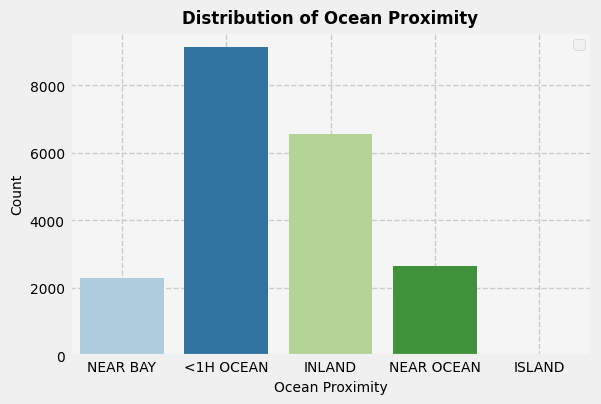

In [5]:
# Visualization - Distribution of Ocean Proximity
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.countplot(data = df_cali_house, x = 'ocean_proximity', palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Distribution of Ocean Proximity', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Ocean Proximity', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

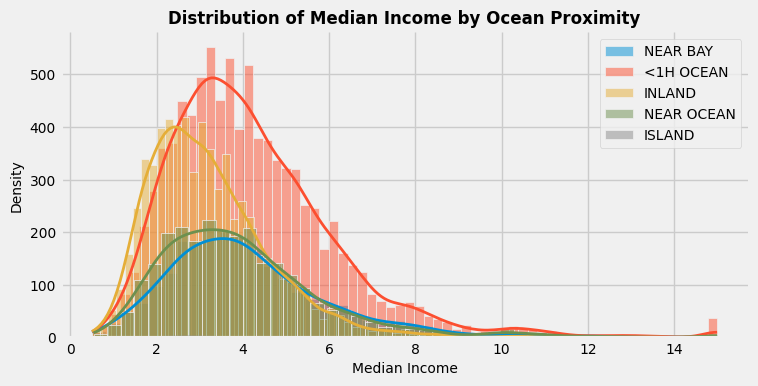

In [6]:
# Visualization - Distribution of Median Income by Ocean Proximity
fig = sns.FacetGrid(df_cali_house, hue = 'ocean_proximity', height = 4, aspect = 2)
fig.map(sns.histplot, 'median_income', kde = True, line_kws = {'lw': 2})
fig.set_axis_labels('Median Income', 'Density', fontsize = 10) 
plt.title('Distribution of Median Income by Ocean Proximity', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

#### ``Data Pre-Processing``

In [7]:
# NA-values
df_cali_house['total_bedrooms'].fillna(df_cali_house['total_bedrooms'].median(), inplace = True)
for col in df_cali_house.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_cali_house[col].isnull().sum()))

longitude column missing values: 0
latitude column missing values: 0
housing_median_age column missing values: 0
total_rooms column missing values: 0
total_bedrooms column missing values: 0
population column missing values: 0
households column missing values: 0
median_income column missing values: 0
median_house_value column missing values: 0
ocean_proximity column missing values: 0


In [8]:
# Feature Selection + Target
X = df_cali_house.drop(['median_house_value'], axis = 1)
Y = df_cali_house['median_house_value']
print(X.shape)
print(Y.shape)

(20640, 9)
(20640,)


In [9]:
# Categorical features
encoder = LabelEncoder()
X['ocean_proximity'] = encoder.fit_transform(X['ocean_proximity'])
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3


In [10]:
# Numerical features
sc = StandardScaler()

numerical_variables = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in numerical_variables:
    X[[col]] = sc.fit_transform(X[[col]])
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,3
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,3
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,3
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,3
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,3


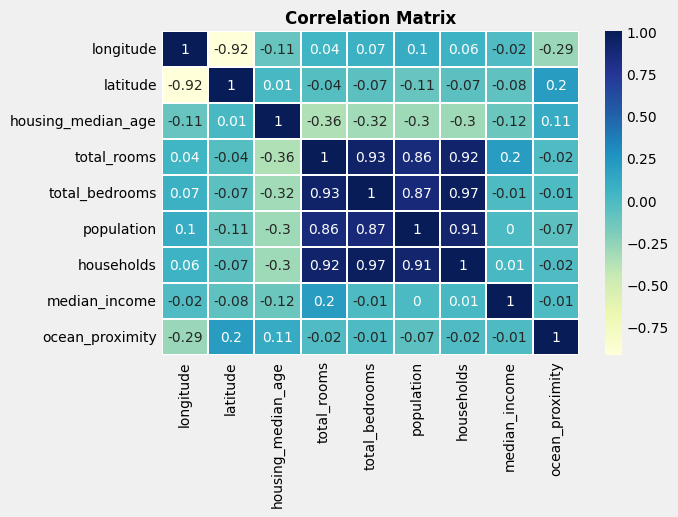

In [11]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [12]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(15480, 9)
(15480,)
(5160, 9)
(5160,)


#### ``Modelling``

In [13]:
# Neural Network model
model_nn = Sequential(name = 'Model_NN')

model_nn.add(Dense(256, activation = 'relu', input_shape = (X_train.shape[1],), kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_1'))
model_nn.add(Dropout(0.2, name = 'dropout_1'))

model_nn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_2'))
model_nn.add(Dropout(0.2, name = 'dropout_2'))

model_nn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_3'))
model_nn.add(Dropout(0.2, name = 'dropout_3'))

model_nn.add(Dense(64, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_4'))
model_nn.add(Dropout(0.2, name = 'dropout_4'))

model_nn.add(Dense(32, activation = 'relu', name = 'hidden_layer_5'))

model_nn.add(Dense(1, name = 'output_layer'))

model_nn.summary()

Model: "Model_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_5 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,337 (243.50 KB)

 Trainable params: 62,337 (243.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compilation + Training
model_nn.compile(loss = 'mae', optimizer = Adam(learning_rate = 0.002), metrics = ['mse'])
history_nn = model_nn.fit(X_train, Y_train, epochs = 1000, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 160948.9062 - mse: 40409751552.0000 - val_loss: 53671.9141 - val_mse: 6156389376.0000
Epoch 2/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 54571.7500 - mse: 6161100800.0000 - val_loss: 46762.8320 - val_mse: 4857653248.0000
Epoch 3/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49392.8203 - mse: 5031386112.0000 - val_loss: 45952.3867 - val_mse: 4646832128.0000
Epoch 4/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49204.4180 - mse: 5109015552.0000 - val_loss: 46298.9648 - val_mse: 4879428096.0000
Epoch 5/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 48883.7070 - mse: 5033369088.0000 - val_loss: 45487.5508 - val_mse: 4597134848.0000
Epoch 6/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 48325.7500 - mse: 4765845504.0000 - val_loss: 44720.2695 - val_mse: 4328519680.0000
Epoch 7/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47645.5234 - mse: 4804505088.0000 - val_loss: 44393.6484 - v

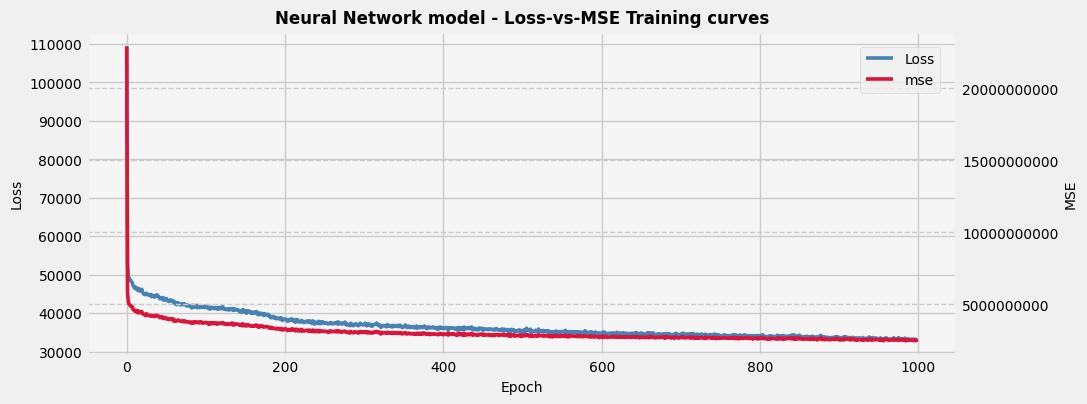

In [15]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_nn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_nn.history['mse'], label = 'mse', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('MSE', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.86), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [16]:
# Model Prediction
y_test_pred = model_nn.predict(X_test, verbose = 0).flatten()

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_test_pred)
mse_dt = mean_squared_error(Y_test, y_test_pred)
print(f'Neural Network model \n -> MAE = {mae_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Neural Network model 
 -> MAE = 53533.9283 
 -> MSE = 5602623273.6159


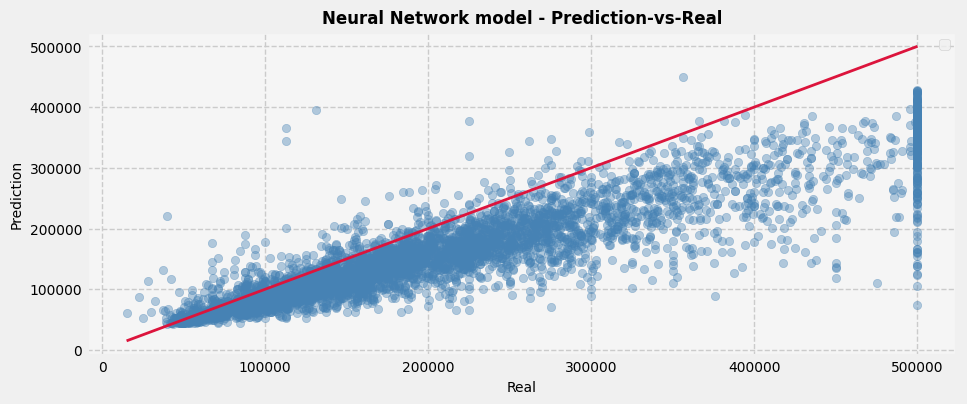

In [17]:
# Prediction-vs-Real
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.scatter(Y_test, y_test_pred, color = 'steelblue', alpha = 0.4)
ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color = 'crimson', linewidth = 2) # reference line
ax.set_ylabel('Prediction', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Real', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Prediction-vs-Real', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

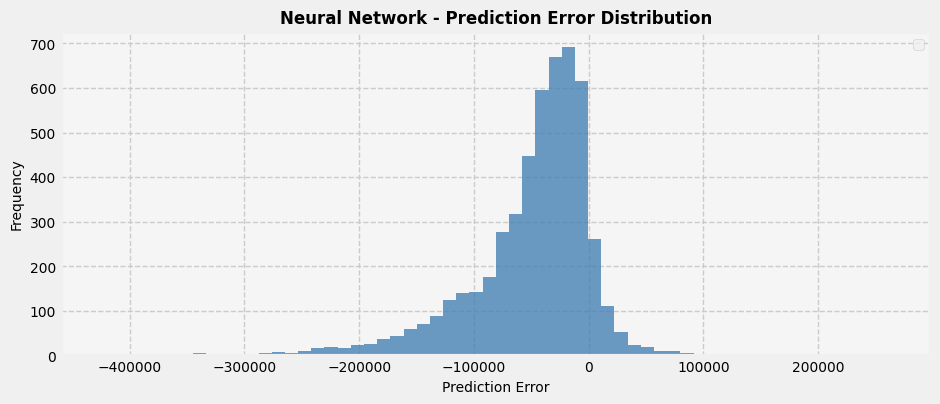

In [18]:
# Prediction Error
errors = y_test_pred - Y_test
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.hist(errors, bins = 60, color = 'steelblue', alpha = 0.8)
ax.set_ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Prediction Error', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network - Prediction Error Distribution', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

In [19]:
# Convolutional Neural Network model

X_train = X_train.values.reshape(-1, 9, 1)
X_test = X_test.values.reshape(-1, 9, 1)
Y_train = Y_train.values.reshape(-1, 1)
Y_test = Y_test.values.reshape(-1, 1)

model_cnn = Sequential(name = 'Model_CNN')

model_cnn.add(Conv1D(64, 3, activation = 'relu', input_shape = (X_train.shape[1], 1), padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_1'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_1'))
model_cnn.add(Dropout(0.2, name = 'dropout_1'))

model_cnn.add(Conv1D(128, 3, activation = 'relu', padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_2'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_2'))
model_cnn.add(Dropout(0.2, name = 'dropout_2'))

model_cnn.add(Conv1D(256, 3, activation = 'relu', padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_3'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_3'))
model_cnn.add(Dropout(0.2, name = 'dropout_3'))

model_cnn.add(Flatten(name = 'flatten_layer'))

model_cnn.add(Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_1'))
model_cnn.add(Dropout(0.2, name = 'dropout_4'))

model_cnn.add(Dense(64, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_2'))
model_cnn.add(Dropout(0.2, name = 'dropout_5'))

model_cnn.add(Dense(1, name = 'output_layer'))

model_cnn.summary()

Model: "Model_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_layer_1 (Conv1D)            │ (None, 9, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_layer_2 (Conv1D)            │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_layer_3 (Conv1D)            │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling1D)        │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,737 (643.50 KB)

 Trainable params: 164,737 (643.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compilation + Training
model_cnn.compile(loss = 'mae', optimizer = Adam(learning_rate = 0.002), metrics = ['mse'])
history_cnn = model_cnn.fit(X_train, Y_train, epochs = 1000, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 152390.3125 - mse: 36156751872.0000 - val_loss: 76990.5078 - val_mse: 11241050112.0000
Epoch 2/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 73677.6328 - mse: 10385069056.0000 - val_loss: 60400.0625 - val_mse: 7022536192.0000
Epoch 3/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 62729.4180 - mse: 7394100224.0000 - val_loss: 54637.4023 - val_mse: 6162990080.0000
Epoch 4/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 60294.2188 - mse: 6931333632.0000 - val_loss: 55715.6055 - val_mse: 5793064960.0000
Epoch 5/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 60331.5898 - mse: 6883578880.0000 - val_loss: 53029.4570 - val_mse: 5631632896.0000
Epoch 6/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 58586.5156 - mse: 6551272960.0000 - val_loss: 52389.8047 - val_mse: 5579612672.0000
Epoch 7/1000
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 58203.4688 - mse: 6516764672.0000 - val_loss: 51443.3398 -

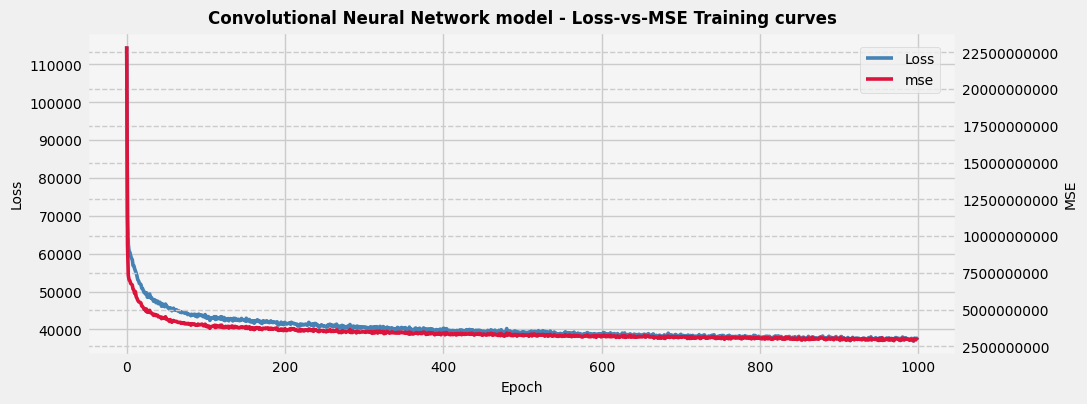

In [21]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_cnn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_cnn.history['mse'], label = 'mse', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('MSE', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.86), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [22]:
# Model Prediction
Y_test = Y_test.flatten()
y_test_pred = model_cnn.predict(X_test, verbose = 0).flatten()

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_test_pred)
mse_dt = mean_squared_error(Y_test, y_test_pred)
print(f'Convolutional Neural Network model \n -> MAE = {mae_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Convolutional Neural Network model 
 -> MAE = 35080.3496 
 -> MSE = 3023619637.8153


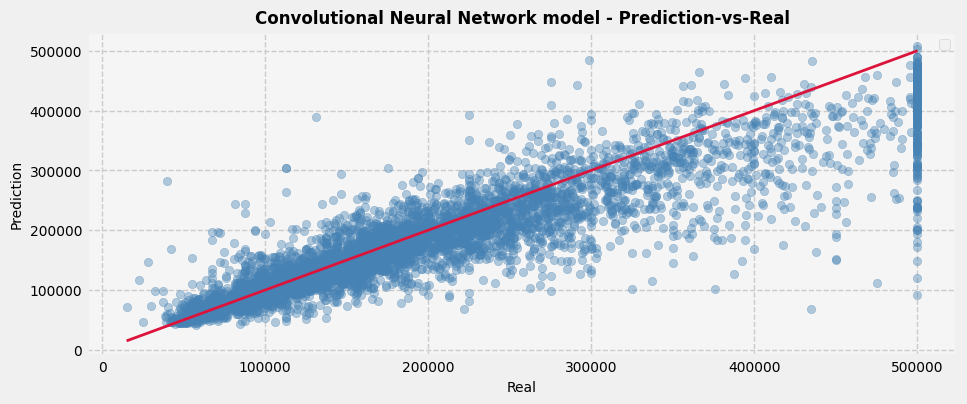

In [23]:
# Prediction-vs-Real
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.scatter(Y_test, y_test_pred, color = 'steelblue', alpha = 0.4)
ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color = 'crimson', linewidth = 2) # reference line
ax.set_ylabel('Prediction', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Real', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Prediction-vs-Real', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

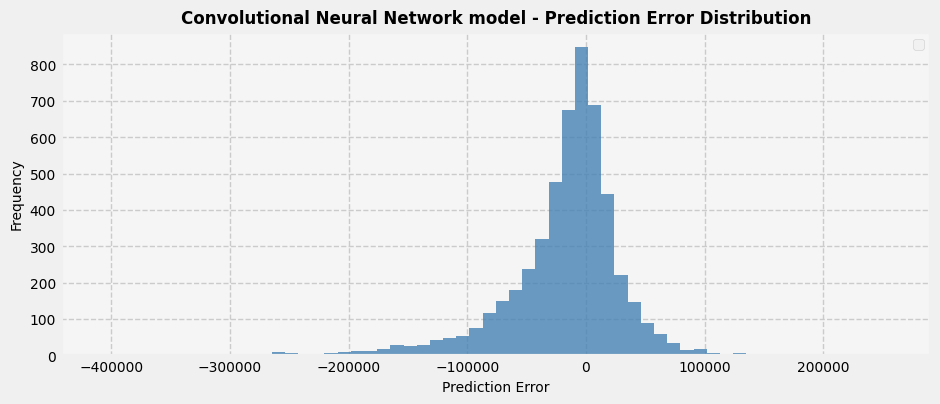

In [24]:
# Prediction Error
errors = y_test_pred - Y_test
fig = plt.figure(figsize = (10, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
ax.hist(errors, bins = 60, color = 'steelblue', alpha = 0.8)
ax.set_ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
ax.set_xlabel('Prediction Error', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Prediction Error Distribution', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

Which is the **``best performing model``**?  

Let us recall that the best performing model in terms of **Machine Learning** was **Random Forest Regressor (RF) model**, with $MAE = 32.171,3840$ and $MSE = 2,46B$, delivering the best performance among the models tested.  

- The **Neural Network (NN) model**: recorded a significantly higher $MAE = 53.533,9283$ and $MSE = 5,60B$. Despite the model's complexity and its ability to learn non-linear relationships, it underperformed compared to **Random Forest**, suggesting possible issues with generalization or hyperparameter tuning.  

- The **Convolutional Neural Network (CNN) model**: achieved $MAE = 35.080,3496$ and $MSE = 3,02B$. While **CNNs** are powerful for tasks like image recognition, they did not outperform **Random Forest** in this regression task, demonstrating that for structured data, simpler models like the latest may provide better results.  

The **``Random Forest Regressor (RF) model``** remains the **best performing model**, providing the lowest error metrics and effectively modeling complex, non-linear relationships in the data. It continues to be the most suitable choice for this task.  

Furthermore, ensemble boosting methods such as **XGBoost** or **LightGBM** are promising alternatives. These models often outperform traditional ones by further reducing bias and variance — making them strong candidates for future improvements.